# 1. Preparation

## 1.1 Prepare environment

In [1]:
# List all NVIDIA GPUs as available in this computer (or Colab's session)
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [2]:
!pip install torchinfo

In [3]:
import sys
print( f"Python {sys.version}\n" )

import random
import time

import numpy as np
print( f"NumPy {np.__version__}\n" )

import matplotlib.pyplot as plt
%matplotlib inline

import torchinfo
print( f"torchinfo {torchinfo.__version__}" )

# https://docs.pytorch.org/vision/0.21/transforms.html
import torchvision
print( f"torchvision {torchvision.__version__}" )

import torch
print( f"PyTorch {torch.__version__}" )

# Get all available accelerators such as CUDA, MPS, MTIA, or XPU
num_accelerators = torch.accelerator.device_count()

if (num_accelerators <= 0):
    print("|- No hardware accelerators found. Using CPU only.")
else:
    print(f"|- PyTorch detected {num_accelerators} hardware accelerator(s)")
    print(f"|- PyTorch detected '{torch.accelerator.current_accelerator().type.upper()}' as the current accelerator")

    # Check cuda availability
    if torch.cuda.is_available():
        num_gpus = torch.cuda.device_count()
        print(f"|- PyTorch detected {num_gpus} CUDA GPU(s):")

        # Important: The CUDA version in "nvidia-smi" must be equal or higher than "torch.version.cuda".
        # If they mismatch, it may cause silent hangs during heavy CUDA operations.
        # In that case, reinstall PyTorch from pytorch.org with the correct CUDA version.
        print(f"   |- {torch.version.cuda = }")
    for i in range(num_gpus):
        print(f"   |- CUDA GPU {i}: {torch.cuda.get_device_name(i)}")

Python 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]

NumPy 2.1.3

torchinfo 1.8.0
torchvision 0.26.0+cpu
PyTorch 2.11.0+cpu
|- No hardware accelerators found. Using CPU only.


## 1.2 Prepare global variables/functions

In [4]:
# Detect GPU (CUDA), Apple Silicon (MPS), or fallback to CPU
# 'device' is a scalar flag, not a tensor
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


# 2. Load the pre-trained CNN model

In [5]:
resnet_weights = torchvision.models.ResNet50_Weights.DEFAULT
resnet = torchvision.models.resnet50(weights=resnet_weights)
resnet

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 128MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [6]:
torchinfo.summary(resnet)

Layer (type:depth-idx)                   Param #
ResNet                                   --
├─Conv2d: 1-1                            9,408
├─BatchNorm2d: 1-2                       128
├─ReLU: 1-3                              --
├─MaxPool2d: 1-4                         --
├─Sequential: 1-5                        --
│    └─Bottleneck: 2-1                   --
│    │    └─Conv2d: 3-1                  4,096
│    │    └─BatchNorm2d: 3-2             128
│    │    └─Conv2d: 3-3                  36,864
│    │    └─BatchNorm2d: 3-4             128
│    │    └─Conv2d: 3-5                  16,384
│    │    └─BatchNorm2d: 3-6             512
│    │    └─ReLU: 3-7                    --
│    │    └─Sequential: 3-8              16,896
│    └─Bottleneck: 2-2                   --
│    │    └─Conv2d: 3-9                  16,384
│    │    └─BatchNorm2d: 3-10            128
│    │    └─Conv2d: 3-11                 36,864
│    │    └─BatchNorm2d: 3-12            128
│    │    └─Conv2d: 3-13               

# 3. Prepare the input image

In [7]:
# Load a test image from Internet
!wget "https://www.dogbreedinfo.com/images21/Pomeranianommania%20PoetryInMotionandPommaniaMsDynamite.jpg"

--2026-09-03 17:32:27--  https://www.dogbreedinfo.com/images21/Pomeranianommania%20PoetryInMotionandPommaniaMsDynamite.jpg
Resolving www.dogbreedinfo.com (www.dogbreedinfo.com)... 192.124.249.54
Connecting to www.dogbreedinfo.com (www.dogbreedinfo.com)|192.124.249.54|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50309 (49K) [image/jpeg]
Saving to: ‘Pomeranianommania PoetryInMotionandPommaniaMsDynamite.jpg’

Pomeranianommania P 100%[===================>]  49.13K  --.-KB/s    in 0.001s  

2026-09-03 17:32:27 (36.5 MB/s) - ‘Pomeranianommania PoetryInMotionandPommaniaMsDynamite.jpg’ saved [50309/50309]



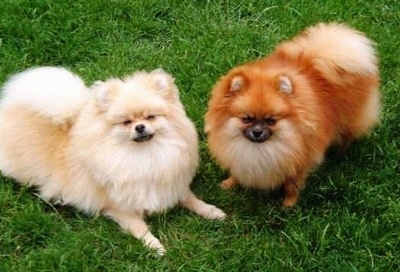

type(img) = <class 'PIL.JpegImagePlugin.JpegImageFile'>
|-> img.size = (400, 272)
|-> img.mode = 'RGB'
|-> Min/Max = ((0, 255), (0, 254), (0, 255))


In [8]:
img_path = 'Pomeranianommania PoetryInMotionandPommaniaMsDynamite.jpg'

# Load an image as PIL.Image.Image
from PIL import Image
img = Image.open(img_path)
display(img)

print(f"{type(img) = }")
print(f"|-> {img.size = }")
print(f"|-> {img.mode = }")
print(f"|-> Min/Max = {img.getextrema()}")

In [9]:
# Get the specific preprocessing transform for the selected weights
resnet_preprocess = resnet_weights.transforms()
resnet_preprocess

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [10]:
img_resnet = resnet_preprocess(img)

print(f"{type(img_resnet) = }")
print(f"|-> {img_resnet.shape = }")
print(f"|-> {img_resnet.dtype = }")
print(f"|-> Min = {torch.min(img_resnet)}")
print(f"|-> Max = {torch.max(img_resnet)}")

type(img_resnet) = <class 'torch.Tensor'>
|-> img_resnet.shape = torch.Size([3, 224, 224])
|-> img_resnet.dtype = torch.float32
|-> Min = -2.0836544036865234
|-> Max = 2.6225709915161133


# 4. Use the pre-trained model

In [13]:
# Access the ImageNet class labels (categories)
imagenet_classes = resnet_weights.meta["categories"]
_ = [ print(f"[{i}] {x}") for i,x in enumerate(imagenet_classes) ]

[0] tench
[1] goldfish
[2] great white shark
[3] tiger shark
[4] hammerhead
[5] electric ray
[6] stingray
[7] cock
[8] hen
[9] ostrich
[10] brambling
[11] goldfinch
[12] house finch
[13] junco
[14] indigo bunting
[15] robin
[16] bulbul
[17] jay
[18] magpie
[19] chickadee
[20] water ouzel
[21] kite
[22] bald eagle
[23] vulture
[24] great grey owl
[25] European fire salamander
[26] common newt
[27] eft
[28] spotted salamander
[29] axolotl
[30] bullfrog
[31] tree frog
[32] tailed frog
[33] loggerhead
[34] leatherback turtle
[35] mud turtle
[36] terrapin
[37] box turtle
[38] banded gecko
[39] common iguana
[40] American chameleon
[41] whiptail
[42] agama
[43] frilled lizard
[44] alligator lizard
[45] Gila monster
[46] green lizard
[47] African chameleon
[48] Komodo dragon
[49] African crocodile
[50] American alligator
[51] triceratops
[52] thunder snake
[53] ringneck snake
[54] hognose snake
[55] green snake
[56] king snake
[57] garter snake
[58] water snake
[59] vine snake
[60] night snak

In [14]:
# --- INFERENCE ---

resnet = resnet.to(device)
resnet.eval()
with torch.inference_mode():
    # Add the batch dimension (B, C, H, W)
    img_batch = img_resnet.unsqueeze(0)

    # Forward pass
    img_batch = img_batch.to(device)
    output_logit = resnet(img_batch)

# Convert logits to probabilities
output_prob = torch.nn.functional.softmax(output_logit, dim=1)

In [18]:
# Get top-k predictions
K = 20
top_prob, top_idx = torch.topk(output_prob, K)

# Print the top K results
print(f"Top {K} predictions:")
for i in range(K):
    prob = top_prob[0][i].item()
    class_idx = top_idx[0][i].item()

    class_name = imagenet_classes[class_idx]
    print(f"  {i+1}: {class_name} (Probability: {prob * 100:.2f}%)")

Top 20 predictions:
  1: Pomeranian (Probability: 55.00%)
  2: keeshond (Probability: 3.17%)
  3: Pekinese (Probability: 0.63%)
  4: chow (Probability: 0.52%)
  5: Japanese spaniel (Probability: 0.35%)
  6: radio (Probability: 0.34%)
  7: papillon (Probability: 0.30%)
  8: Samoyed (Probability: 0.27%)
  9: tennis ball (Probability: 0.20%)
  10: Tibetan terrier (Probability: 0.17%)
  11: microphone (Probability: 0.16%)
  12: affenpinscher (Probability: 0.12%)
  13: Brabancon griffon (Probability: 0.12%)
  14: toy poodle (Probability: 0.12%)
  15: torch (Probability: 0.11%)
  16: indri (Probability: 0.10%)
  17: Chihuahua (Probability: 0.10%)
  18: Sussex spaniel (Probability: 0.10%)
  19: polecat (Probability: 0.09%)
  20: ballpoint (Probability: 0.09%)
